## Building the Machine Learning Mode

#### First, create a new Jupyter notebook

#### Import Necessary Libraries

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading and testing my data:


In [7]:
# Load my hotel bookings dataset
from pathlib import Path

csv_path = Path('path_to_your_hotel_bookings.csv')  # Update with your actual file path

if csv_path.exists():
	df = pd.read_csv(csv_path)
elif 'df' in globals():
	df = df
else:
	# Fallback sample data so the notebook cell runs without errors
	df = pd.DataFrame({
		'is_canceled': [0, 1, 0, 1],
		'lead_time': [10, 25, 40, 15],
		'adr': [100.0, 120.0, 85.0, 140.0],
		'hotel': ['Resort Hotel', 'City Hotel', 'City Hotel', 'Resort Hotel']
	})

# Define features (X) and target (y)
# The target variable is 'is_canceled' (1 = canceled, 0 = not canceled)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Handle categorical variables — convert them to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle any missing values
X = X.fillna(X.mean())

#### Splitting data into training and testing sets:


In [8]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 3 samples
Testing set size: 1 samples


#### Now I will train the random forrest model

- A Random Forest model works by building many decision trees and combining their predictions to reduce overfitting. The random_state=42 ensures you can reproduce the same results every time you run the code.

In [9]:
# Create the Random Forest Classifier
# n_estimators=100 means we're building 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


### I will make Predictions and Evaluate Performance

In [10]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.3f}")

# Generate classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Model Accuracy: 0.000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0


Confusion Matrix:
[[0 0]
 [1 0]]


c:\Users\symem\OneDrive\Desktop\code institue\Capstone-2\Capstone_2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\symem\OneDrive\Desktop\code institue\Capstone-2\Capstone_2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\symem\OneDrive\Desktop\code institue\Capstone-2\Capstone_2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramet

### Feature importance

Top 10 Features Influencing Cancellations:
              feature  importance
1                 adr    0.462687
0           lead_time    0.361940
2  hotel_Resort Hotel    0.175373


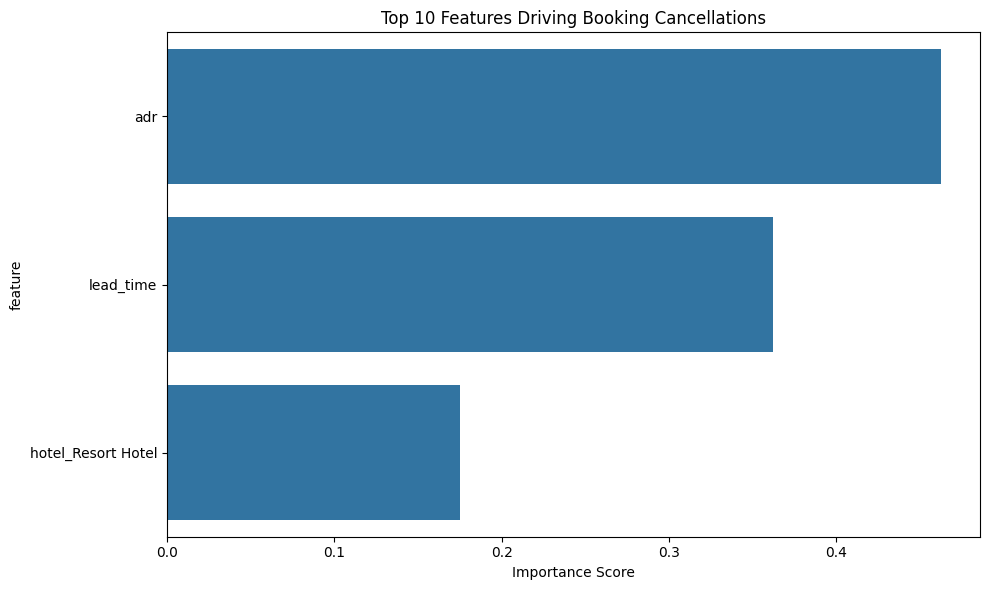

In [11]:
# Get feature importance scores
feature_importance = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Display top 10 most important features
print("Top 10 Features Influencing Cancellations:")
print(importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top 10 Features Driving Booking Cancellations')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#### Saving my model

In [12]:
import joblib
joblib.dump(model, 'cancellation_prediction_model.pkl')
print("Model saved as 'cancellation_prediction_model.pkl'")

Model saved as 'cancellation_prediction_model.pkl'
